In [2]:
import re
import pandas as pd

ABUSIVE_WORDS = {
    "mild_abuse": [
        "idiot",
        "stupid",
        "moron",
        "dumb",
        "loser",
        "fool",
        "jerk",
    ],

    "strong_abuse": [
        "Basterd","Fuck",
    ],

    "threat": [
        "i will hurt you",
        "i'll hurt you",
        "i will kill you",
        "i'll kill you",
        "you will pay",
    ],

    "harassment": [
        "shut up",
        "go away",
        "nobody likes you",
    ]
}

In [3]:


def normalize_text(text):
    """
    Normalize text before checking for abusive language.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize repeated characters:
    # e.g. "stuuupid" -> "stuupid"
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Replace punctuation with spaces
    text = re.sub(r"[^a-z0-9\s']", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text




In [4]:
def phrase_exists(text, phrase):
    """
    Checks a complete word/phrase rather than simple substring
    matching to reduce false positives.
    """

    phrase = normalize_text(phrase)

    if not phrase:
        return False

    pattern = r"(?<!\w)" + re.escape(phrase) + r"(?!\w)"

    return re.search(pattern, text) is not None


In [5]:
def detect_violation(text):
    """
    Multi-label violation detection.

    A message can belong to multiple categories at the same time.

    Returns:
        violation
        categories
        matched_terms
        score
    """

    normalized_text = normalize_text(text)

    if not normalized_text:
        return {
            "violation": False,
            "categories": [],
            "matched_terms": {},
            "score": 0
        }

    matched_terms = {}
    categories = []

    for category, words in ABUSIVE_WORDS.items():

        category_matches = []

        for word in words:

            if phrase_exists(normalized_text, word):
                category_matches.append(word)


        if category_matches:

            categories.append(category)

            matched_terms[category] = category_matches


    if not categories:

        return {
            "violation": False,
            "categories": [],
            "matched_terms": {},
            "score": 0
        }

    total_matches = sum(
        len(words)
        for words in matched_terms.values()
    )

    score = min(total_matches / 5, 1.0)


    return {
        "violation": True,
        "categories": categories,
        "matched_terms": matched_terms,
        "score": round(score, 2)
    }


In [6]:
message = """
You are a stupid idiot.
Nobody likes you.
I will hurt you.
"""
result = detect_violation(message)

print(result)


{'violation': True, 'categories': ['mild_abuse', 'threat', 'harassment'], 'matched_terms': {'mild_abuse': ['idiot', 'stupid'], 'threat': ['i will hurt you'], 'harassment': ['nobody likes you']}, 'score': 0.8}


In [7]:

if __name__ == "__main__":

    message = input("Enter a message: ")

    result = detect_violation(message)
    
    print("Message:")
    print(message)
    
    print("\nViolation:", result["violation"])
    print("Categories:", result["categories"])
    print("Matched terms:", result["matched_terms"])
    print("Score:", result["score"])


Message:
hey bloody man

Violation: False
Categories: []
Matched terms: {}
Score: 0


In [8]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [9]:
import sys
print(sys.executable)

/Users/ajay/jupyter/anaconda3/bin/python


In [10]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders:")
print(os.listdir())


Current directory:
/Users/ajay/baseline_models/models

Files/folders:
['message_violation_detection_baseline_model.ipynb']


In [11]:
import sys
import numpy
import scipy
import sklearn

print("Python:")
print(sys.executable)

print("\nNumPy:")
print(numpy.__version__)

print("\nSciPy:")
print(scipy.__version__)

print("\nScikit-learn:")
print(sklearn.__version__)

from scipy.sparse import csr_matrix

print("\ncsr_matrix:")
print(csr_matrix)

print("\nEverything is working!")


Python:
/Users/ajay/jupyter/anaconda3/bin/python

NumPy:
2.5.3

SciPy:
1.16.3

Scikit-learn:
1.9.1

csr_matrix:
<class 'scipy.sparse._csr.csr_matrix'>

Everything is working!


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss
)

In [20]:
df = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_train.csv")

print("Dataset shape:", df.shape)

display(df.head())


Dataset shape: (120000, 2)


,comment_text,toxic
0,"Wasn't me, asshole. Check your fucking IP's b...",1
1,Stupid law. Why does Quebec always have to ca...,1
2,after qualifying for the Wimbledon main draw -...,1
3,THE QUESTION IS NOT WHETHER IT'S ART OR PORNOG...,1
4,fuck you white trash!!!,1


In [21]:
print(df.columns)
print(df["toxic"].value_counts())

Index(['comment_text', 'toxic'], dtype='str')
toxic
1    60000
0    60000
Name: count, dtype: int64


In [23]:
train = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_train.csv")
test = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_test.csv")
validation = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_validation.csv")

print("TRAIN:")
print(train.shape)
print(train.columns.tolist())

print("\nTEST:")
print(test.shape)
print(test.columns.tolist())

print("\nVALIDATION:")
print(validation.shape)
print(validation.columns.tolist())


TRAIN:
(120000, 2)
['comment_text', 'toxic']

TEST:
(20000, 2)
['comment_text', 'toxic']

VALIDATION:
(20000, 2)
['comment_text', 'toxic']


In [24]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
comment_text    0
toxic           0
dtype: int64


In [25]:
print("Number of duplicate comments:")
print(df["comment_text"].duplicated().sum())

Number of duplicate comments:
4646


In [26]:
df = df.drop_duplicates(
    subset=["comment_text"]
).reset_index(drop=True)

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(115354, 2)


In [27]:
print(df["toxic"].value_counts())

toxic
1    58584
0    56770
Name: count, dtype: int64


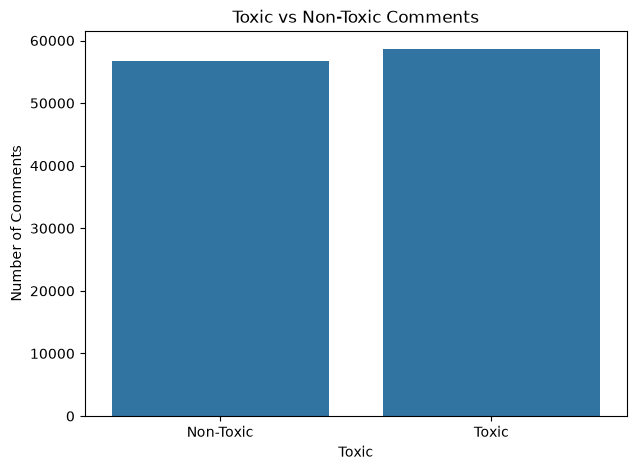

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="toxic",
    data=df
)

plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Toxic")
plt.ylabel("Number of Comments")

plt.xticks(
    [0, 1],
    ["Non-Toxic", "Toxic"]
)

plt.show()


In [29]:
df["text_length"] = df["comment_text"].str.len()
print(df["text_length"].describe())

count    115354.000000
mean        324.385049
std         492.723294
min           1.000000
25%          84.000000
50%         177.000000
75%         366.000000
max        5000.000000
Name: text_length, dtype: float64


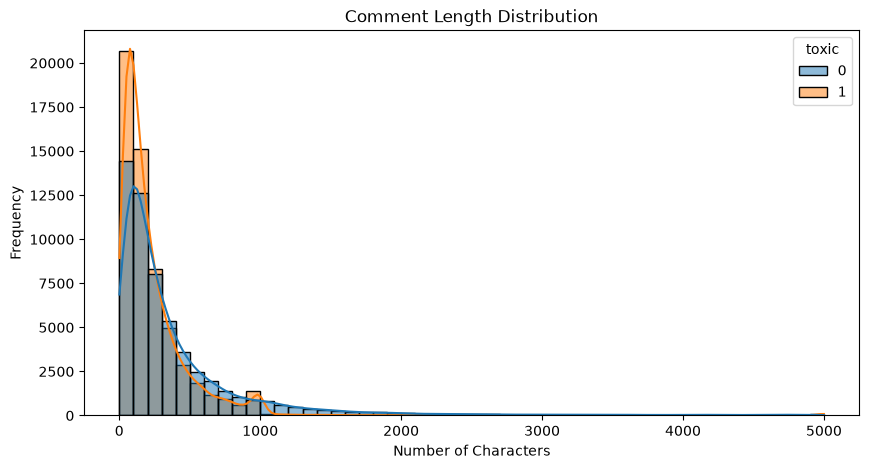

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="text_length",
    hue="toxic",
    bins=50,
    kde=True
)

plt.title("Comment Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()


In [31]:
X = df["comment_text"]
y = df["toxic"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (115354,)
y shape: (115354,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 92283
Testing samples: 23071


In [33]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

In [34]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:")
print(X_train_tfidf.shape)
print("\nTesting TF-IDF shape:")
print(X_test_tfidf.shape)


Training TF-IDF shape:
(92283, 100000)

Testing TF-IDF shape:
(23071, 100000)


In [35]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [36]:
model.fit( X_train_tfidf,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [37]:
y_pred = model.predict(X_test_tfidf)

In [38]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9281


In [39]:
precision = precision_score( y_test, y_pred,zero_division=0)
print("Precision:",round(precision, 4))

Precision: 0.931


In [40]:
recall = recall_score( y_test, y_pred,zero_division=0)
print("Recall:",round(recall, 4))

Recall: 0.9272


In [41]:
f1 = f1_score(y_test,y_pred,zero_division=0)
print("F1 Score:",round(f1, 4))

F1 Score: 0.9291


In [42]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Toxic",
            "Toxic"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Toxic       0.93      0.93      0.93     11354
       Toxic       0.93      0.93      0.93     11717

    accuracy                           0.93     23071
   macro avg       0.93      0.93      0.93     23071
weighted avg       0.93      0.93      0.93     23071



In [43]:
from sklearn.metrics import confusion_matrix

In [44]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


[[10549   805]
 [  853 10864]]


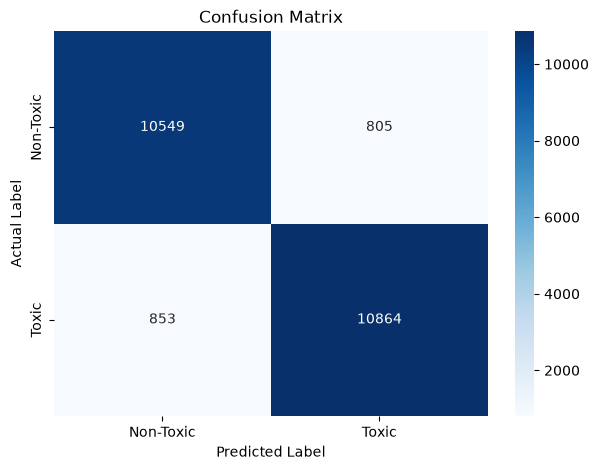

In [45]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-Toxic",
        "Toxic"
    ],
    yticklabels=[
        "Non-Toxic",
        "Toxic"
    ]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [46]:
message = input("Enter a message: ")
message_tfidf = tfidf.transform(
    [message]
)
prediction = model.predict(
    message_tfidf
)[0]

if prediction == 1:
    print("\nViolation: True")
    print("Category: Toxic")
else:
    print("\nViolation: False")
    print("Category: Non-Toxic")



Violation: True
Category: Toxic


In [47]:
message = input("Enter a message: ")

message_tfidf = tfidf.transform(
    [message]
)

probabilities = model.predict_proba(
    message_tfidf
)[0]

non_toxic_probability = probabilities[0]
toxic_probability = probabilities[1]

print("\nMessage:")
print(message)

print(
    "\nNon-Toxic probability:",
    round(non_toxic_probability, 4)
)

print(
    "Toxic probability:",
    round(toxic_probability, 4)
)


Message:
hey man fuck you

Non-Toxic probability: 0.0018
Toxic probability: 0.9982


In [48]:
def predict_message(message, threshold=0.5):

    message_tfidf = tfidf.transform(
        [message]
    )

    probability = model.predict_proba(
        message_tfidf
    )[0][1]

    if probability >= threshold:
        prediction = 1
        label = "Toxic"
    else:
        prediction = 0
        label = "Non-Toxic"

    return {
        "message": message,
        "prediction": prediction,
        "label": label,
        "toxic_probability": round(
            float(probability),
            4
        )
    }

In [49]:
message = input("Enter a message: ")

result = predict_message(message)

print("Message:")
print(result["message"])

print("\nPrediction:")
print(result["prediction"])

print("\nLabel:")
print(result["label"])

print("\nToxic Probability:")
print(result["toxic_probability"])


Message:
hzjsas

Prediction:
0

Label:
Non-Toxic

Toxic Probability:
0.3452


In [50]:
test_messages = [
    "Hello, how are you today?",
    "Thank you for your help.",
    "You are an idiot.",
    "Fuck you.",
    "I hate this stupid situation.",
    "This is a beautiful day.",
    "I will kill you.",
    "You are completely useless."
]

for message in test_messages:

    result = predict_message(message)
    print("Message:", message)

    print(
        "Prediction:",
        result["label"]
    )

    print(
        "Toxic probability:",
        result["toxic_probability"]
    )

Message: Hello, how are you today?
Prediction: Non-Toxic
Toxic probability: 0.3197
Message: Thank you for your help.
Prediction: Non-Toxic
Toxic probability: 0.0435
Message: You are an idiot.
Prediction: Toxic
Toxic probability: 1.0
Message: Fuck you.
Prediction: Toxic
Toxic probability: 1.0
Message: I hate this stupid situation.
Prediction: Toxic
Toxic probability: 0.9967
Message: This is a beautiful day.
Prediction: Non-Toxic
Toxic probability: 0.4366
Message: I will kill you.
Prediction: Toxic
Toxic probability: 0.9851
Message: You are completely useless.
Prediction: Toxic
Toxic probability: 0.8867


In [ ]:
thresholds = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
]

for threshold in thresholds:

    predictions = (
        model.predict_proba(
            X_test_tfidf
        )[:, 1] >= threshold
    ).astype(int)

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold: {threshold}"
    )

    print(
        f"Precision: {precision_value:.4f}"
    )

    print(
        f"Recall: {recall_value:.4f}"
    )

    print(
        f"F1: {f1_value:.4f}"
    )

    print()

Threshold: 0.3
Precision: 0.8484
Recall: 0.9742
F1: 0.9070

Threshold: 0.4
Precision: 0.8947
Recall: 0.9556
F1: 0.9241

Threshold: 0.5
Precision: 0.9274
Recall: 0.9292
F1: 0.9283

Threshold: 0.6
Precision: 0.9510
Recall: 0.8888
F1: 0.9188

Threshold: 0.7
Precision: 0.9690
Recall: 0.8316
F1: 0.8950



In [52]:
import joblib

In [54]:
joblib.dump(
    model,
    "toxicity_logistic_regression.pkl"
)

joblib.dump(
    tfidf,
    "toxicity_tfidf.pkl"
)

print("Model and TF-IDF vectorizer saved successfully.")

Model and TF-IDF vectorizer saved successfully.


In [55]:
model = joblib.load(
    "toxicity_logistic_regression.pkl"
)

tfidf = joblib.load(
    "toxicity_tfidf.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [56]:
result = predict_message(
    "you are an idiot"
)

print(result)

{'message': 'you are an idiot', 'prediction': 1, 'label': 'Toxic', 'toxic_probability': 1.0}


In [58]:
import pandas as pd

val_df = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_validation.csv")
test_df = pd.read_csv("/Users/ajay/baseline_models/datasets/toxic_comment_test.csv")

print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Validation shape: (20000, 2)
Test shape: (20000, 2)


In [59]:
val_df = val_df.dropna(
    subset=["comment_text", "toxic"]
)

test_df = test_df.dropna(
    subset=["comment_text", "toxic"]
)

X_val = val_df["comment_text"]
y_val = val_df["toxic"]

X_test = test_df["comment_text"]
y_test = test_df["toxic"]


In [60]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Validation TF-IDF:", X_val_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Validation TF-IDF: (20000, 100000)
Test TF-IDF: (20000, 100000)


In [61]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

val_probabilities = model.predict_proba(
    X_val_tfidf
)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    val_predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print("-" * 35)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest Threshold:", best_threshold)
print("Best Validation F1:", round(best_f1, 4))


Threshold: 0.3
Precision: 0.8462
Recall:    0.9755
F1:        0.9063
-----------------------------------
Threshold: 0.4
Precision: 0.8959
Recall:    0.9556
F1:        0.9248
-----------------------------------
Threshold: 0.5
Precision: 0.9282
Recall:    0.9264
F1:        0.9273
-----------------------------------
Threshold: 0.6
Precision: 0.9499
Recall:    0.8861
F1:        0.9169
-----------------------------------
Threshold: 0.7
Precision: 0.9663
Recall:    0.8223
F1:        0.8885
-----------------------------------

Best Threshold: 0.5
Best Validation F1: 0.9273


In [62]:
test_probabilities = model.predict_proba(
    X_test_tfidf
)[:, 1]

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

print("FINAL TEST RESULTS")

print(f"Threshold : {best_threshold}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


FINAL TEST RESULTS
Threshold : 0.5
Accuracy  : 0.9276
Precision : 0.9315
Recall    : 0.9232
F1 Score  : 0.9273


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Non-Toxic",
            "Toxic"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

   Non-Toxic       0.92      0.93      0.93     10000
       Toxic       0.93      0.92      0.93     10000

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000

